# Phase 2: US Uncertainty & Markets - Exploratory Analysis

This notebook explores relationships between US Economic Policy Uncertainty (EPU) and asset volatilities (S&P 500, Gold, Bitcoin).

**Objective**: Identify patterns, correlations, and lead-lag relationships to inform modeling decisions.

**Input**: `data/processed/usepu_assets_daily_features.csv`

## 1. Load Processed Data

In [ ]:
# Load merged dataset
df = pd.read_csv(DATA_PROCESSED / 'usepu_assets_daily_features.csv', parse_dates=['Date'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumns: {list(df.columns)}")

# Display first rows
display(df.head())

# Display last rows
print("\nLast rows:")
display(df.tail())

Dataset shape: (2227, 29)
Date range: 2014-01-03 00:00:00 to 2023-11-13 00:00:00

Columns: ['Date', 'EPU', 'ΔEPU', 'EPU_MA30', 'EPU_Std30', 'SP500_Close', 'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Return', 'SP500_Vol7d', 'SP500_Vol30d', 'SP500_Vol90d', 'Gold_Close', 'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Return', 'Gold_Vol7d', 'Gold_Vol30d', 'Gold_Vol90d', 'BTC_Close', 'BTC_Open', 'BTC_High', 'BTC_Low', 'BTC_Return', 'BTC_Vol7d', 'BTC_Vol30d', 'BTC_Vol90d']


,Date,EPU,ΔEPU,EPU_MA30,EPU_Std30,SP500_Close,SP500_Open,SP500_High,SP500_Low,SP500_Return,...,Gold_Vol30d,Gold_Vol90d,BTC_Close,BTC_Open,BTC_High,BTC_Low,BTC_Return,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
0,2014-01-03,113.11,10.03,92.407333,34.711893,1831.4,1833.2,1838.2,1829.1,-0.000328,...,0.012946,0.013518,884.3,856.9,888.2,839.4,NaN,NaN,NaN,NaN
1,2014-01-06,121.14,-23.77,96.903000,35.432950,1826.8,1832.3,1837.2,1823.7,-0.002515,...,0.012768,0.013340,1012.7,1014.7,1093.4,964.7,-0.001973,NaN,NaN,NaN
2,2014-01-07,93.88,-27.26,97.600667,35.149982,1837.9,1828.7,1840.1,1828.7,0.006058,...,0.012657,0.013351,879.9,1012.7,1044.0,879.8,-0.140567,NaN,NaN,NaN
3,2014-01-08,106.42,12.54,98.890667,34.723101,1837.5,1837.9,1840.0,1831.4,-0.000218,...,0.012667,0.013350,938.8,879.9,966.9,858.9,0.064794,NaN,NaN,NaN
4,2014-01-09,60.31,-46.11,97.618667,35.430783,1838.1,1839.0,1843.2,1830.4,0.000326,...,0.012680,0.013313,937.0,938.8,964.6,866.5,-0.001919,NaN,NaN,NaN



Last rows:


,Date,EPU,ΔEPU,EPU_MA30,EPU_Std30,SP500_Close,SP500_Open,SP500_High,SP500_Low,SP500_Return,...,Gold_Vol30d,Gold_Vol90d,BTC_Close,BTC_Open,BTC_High,BTC_Low,BTC_Return,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
2222,2023-11-06,342.88,257.61,144.437667,107.215802,4365.98,4364.27,4372.21,4347.53,0.001751,...,0.009369,0.007859,35042.0,35020.3,35275.6,34742.9,0.000645,0.011610,0.022225,0.019976
2223,2023-11-07,122.59,-220.29,140.894000,106.078748,4378.38,4366.21,4386.26,4355.41,0.002836,...,0.009507,0.007818,35426.1,35042.1,35877.9,34536.9,0.010901,0.012043,0.022168,0.019978
2224,2023-11-08,119.34,-3.25,136.067667,103.541926,4382.78,4384.37,4391.20,4359.76,0.001004,...,0.009459,0.007753,35636.9,35426.2,36050.2,35148.8,0.005933,0.008975,0.021842,0.019971
2225,2023-11-09,142.71,23.37,136.049000,103.540633,4347.35,4391.41,4393.40,4343.94,-0.008117,...,0.009516,0.007776,36700.5,35636.9,37942.0,35578.1,0.029409,0.011609,0.021962,0.020174
2226,2023-11-13,116.21,-28.83,133.770667,101.984184,4411.55,4406.66,4421.76,4393.82,-0.000836,...,0.009630,0.007812,36478.3,37067.8,37404.6,36358.4,-0.015939,0.014887,0.021862,0.020294


In [6]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print("Missing values:")
display(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

Missing values:


,Missing,Percentage
BTC_Vol90d,60,2.694207
BTC_Vol30d,19,0.853166
BTC_Vol7d,5,0.224517
BTC_Return,1,0.044903


## 2. Descriptive Statistics

### 2.1 Summary Statistics

In [7]:
# Key features for analysis
key_features = ['EPU', 'ΔEPU', 'SP500_Return', 'SP500_Vol7d', 'SP500_Vol30d', 'SP500_Vol90d',
                'Gold_Return', 'Gold_Vol7d', 'Gold_Vol30d', 'Gold_Vol90d',
                'BTC_Return', 'BTC_Vol7d', 'BTC_Vol30d', 'BTC_Vol90d']

# Summary statistics
summary = df[key_features].describe()
print("Summary Statistics:")
display(summary)

Summary Statistics:


,EPU,ΔEPU,SP500_Return,SP500_Vol7d,SP500_Vol30d,SP500_Vol90d,Gold_Return,Gold_Vol7d,Gold_Vol30d,Gold_Vol90d,BTC_Return,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
count,2227.000000,2227.000000,2227.000000,2227.000000,2227.000000,2227.000000,2227.000000,2227.000000,2227.000000,2227.000000,2226.000000,2222.000000,2208.000000,2167.000000
mean,118.727741,-10.472901,0.000306,0.008962,0.009483,0.009924,0.000250,0.008782,0.009290,0.009504,0.000795,0.033794,0.037870,0.038642
std,93.575441,64.836913,0.011332,0.007299,0.006357,0.005579,0.009602,0.004055,0.002803,0.002152,0.056960,0.040698,0.037359,0.026508
min,3.320000,-381.670000,-0.127657,0.001073,0.002244,0.003507,-0.051140,0.001936,0.004496,0.006195,-0.848829,0.002766,0.007046,0.011736
25%,61.130000,-37.935000,-0.003912,0.004732,0.005934,0.006864,-0.004515,0.006145,0.007358,0.007788,-0.014548,0.017905,0.023594,0.027174
50%,91.150000,-7.710000,0.000533,0.007203,0.007841,0.008573,0.000157,0.008017,0.008705,0.009030,0.000706,0.027240,0.032211,0.033663
75%,140.220000,20.545000,0.005586,0.011023,0.011341,0.011577,0.005363,0.010477,0.010348,0.010840,0.018604,0.040755,0.042366,0.041765
max,807.660000,358.280000,0.089671,0.086525,0.054091,0.034246,0.057754,0.034861,0.026443,0.017585,1.474180,0.808068,0.382500,0.222335


In [8]:
# Calculate skewness and kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': df[key_features].skew(),
    'Kurtosis': df[key_features].kurtosis()
})

print("Skewness and Kurtosis:")
display(skew_kurt)

# Interpretation
print("\nInterpretation:")
print("- Skewness > 0: Right-skewed (positive tail)")
print("- Skewness < 0: Left-skewed (negative tail)")
print("- Kurtosis > 3: Heavy tails (leptokurtic)")
print("- Kurtosis < 3: Light tails (platykurtic)")

Skewness and Kurtosis:


,Skewness,Kurtosis
EPU,2.556170,8.726926
ΔEPU,-0.425095,4.468072
SP500_Return,-0.838970,17.232153
SP500_Vol7d,4.477315,33.579260
SP500_Vol30d,3.858770,21.317738
SP500_Vol90d,2.599164,8.011051
Gold_Return,0.039385,3.645278
Gold_Vol7d,1.856798,6.125956
Gold_Vol30d,2.360790,9.340965
Gold_Vol90d,1.325779,2.486288



Interpretation:
- Skewness > 0: Right-skewed (positive tail)
- Skewness < 0: Left-skewed (negative tail)
- Kurtosis > 3: Heavy tails (leptokurtic)
- Kurtosis < 3: Light tails (platykurtic)


### 2.2 Distribution Plots

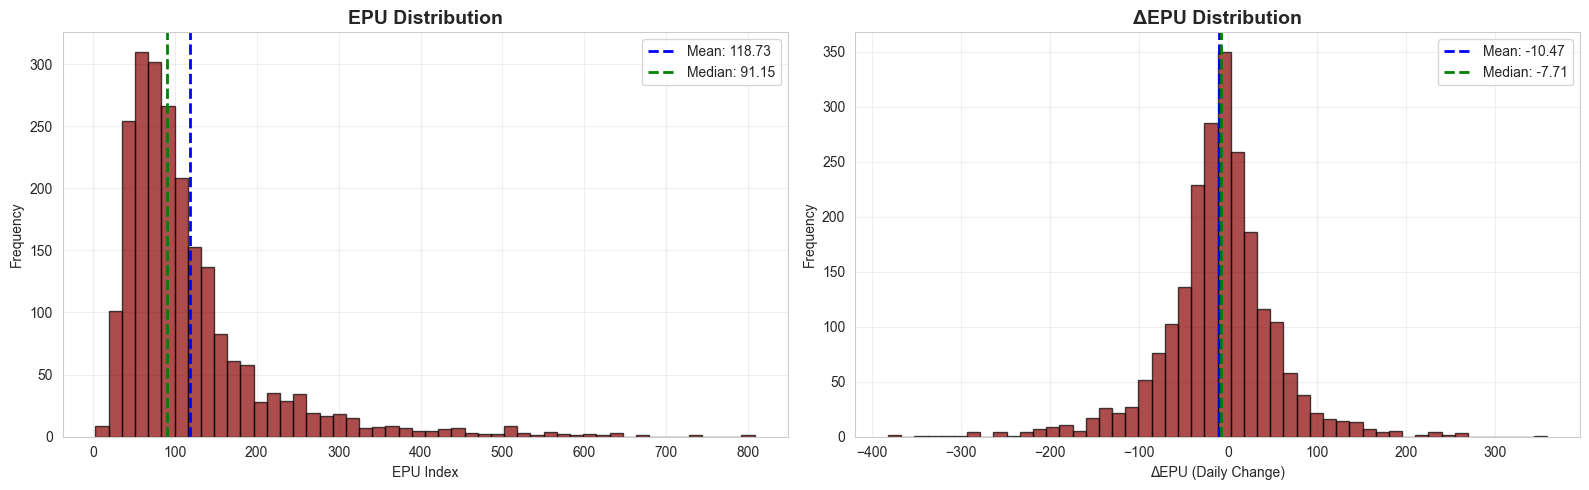

In [9]:
# Distribution plots for EPU features
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# EPU
axes[0].hist(df['EPU'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='darkred')
axes[0].axvline(df['EPU'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {df["EPU"].mean():.2f}')
axes[0].axvline(df['EPU'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["EPU"].median():.2f}')
axes[0].set_title('EPU Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('EPU Index')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ΔEPU
axes[1].hist(df['ΔEPU'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='darkred')
axes[1].axvline(df['ΔEPU'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {df["ΔEPU"].mean():.2f}')
axes[1].axvline(df['ΔEPU'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["ΔEPU"].median():.2f}')
axes[1].set_title('ΔEPU Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ΔEPU (Daily Change)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

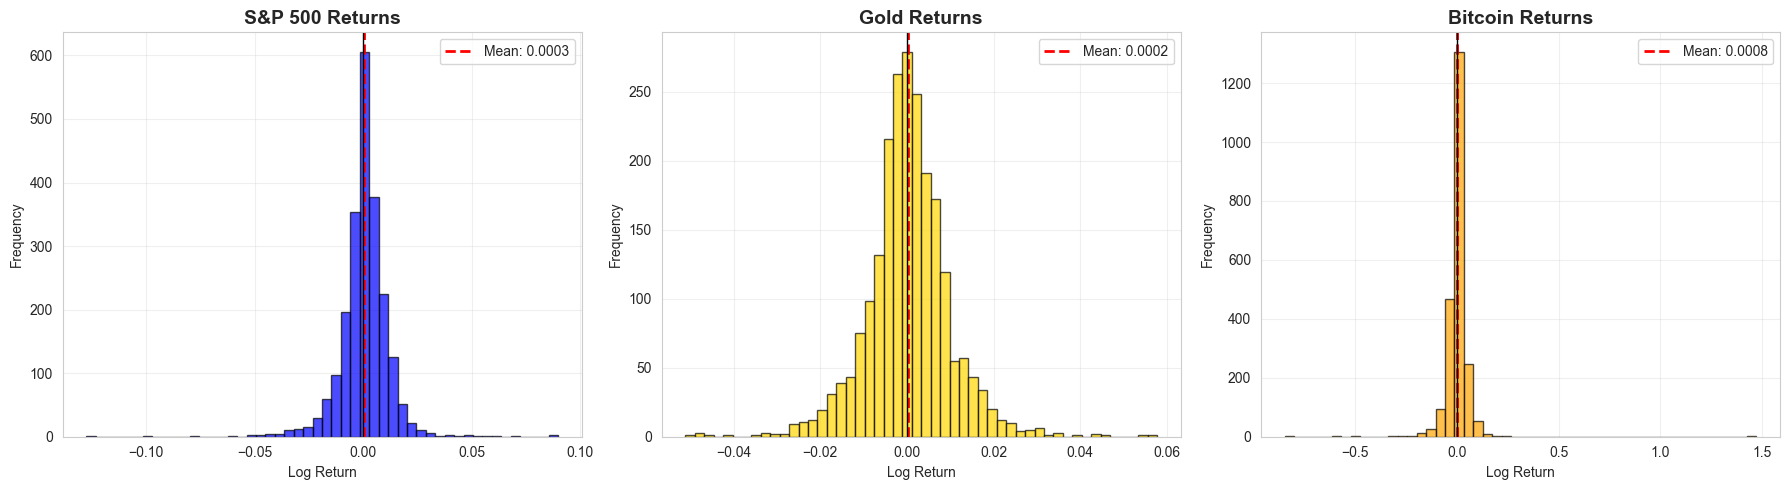

In [10]:
# Distribution plots for returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

returns = ['SP500_Return', 'Gold_Return', 'BTC_Return']
colors = ['blue', 'gold', 'orange']
titles = ['S&P 500 Returns', 'Gold Returns', 'Bitcoin Returns']

for i, (ret, color, title) in enumerate(zip(returns, colors, titles)):
    axes[i].hist(df[ret].dropna(), bins=50, edgecolor='black', alpha=0.7, color=color)
    axes[i].axvline(df[ret].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[ret].mean():.4f}')
    axes[i].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Log Return')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

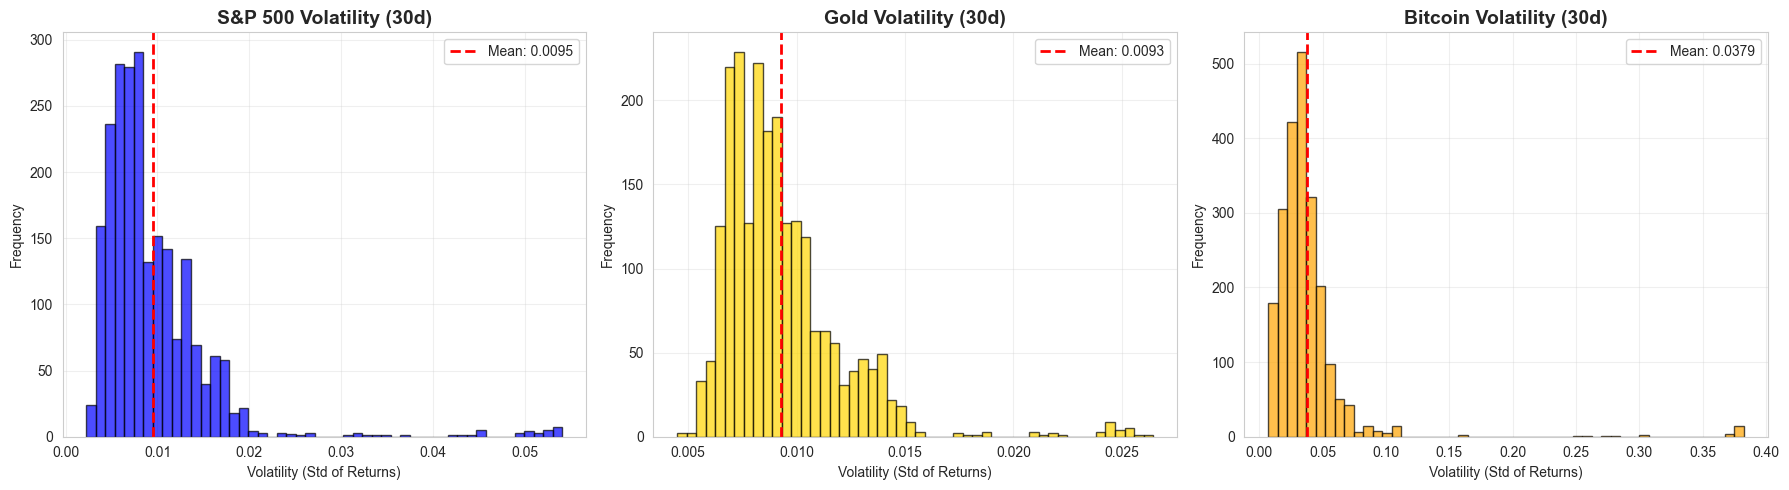

In [11]:
# Distribution plots for 30-day volatilities
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vols = ['SP500_Vol30d', 'Gold_Vol30d', 'BTC_Vol30d']
colors = ['blue', 'gold', 'orange']
titles = ['S&P 500 Volatility (30d)', 'Gold Volatility (30d)', 'Bitcoin Volatility (30d)']

for i, (vol, color, title) in enumerate(zip(vols, colors, titles)):
    axes[i].hist(df[vol].dropna(), bins=50, edgecolor='black', alpha=0.7, color=color)
    axes[i].axvline(df[vol].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[vol].mean():.4f}')
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Volatility (Std of Returns)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 Outlier Detection

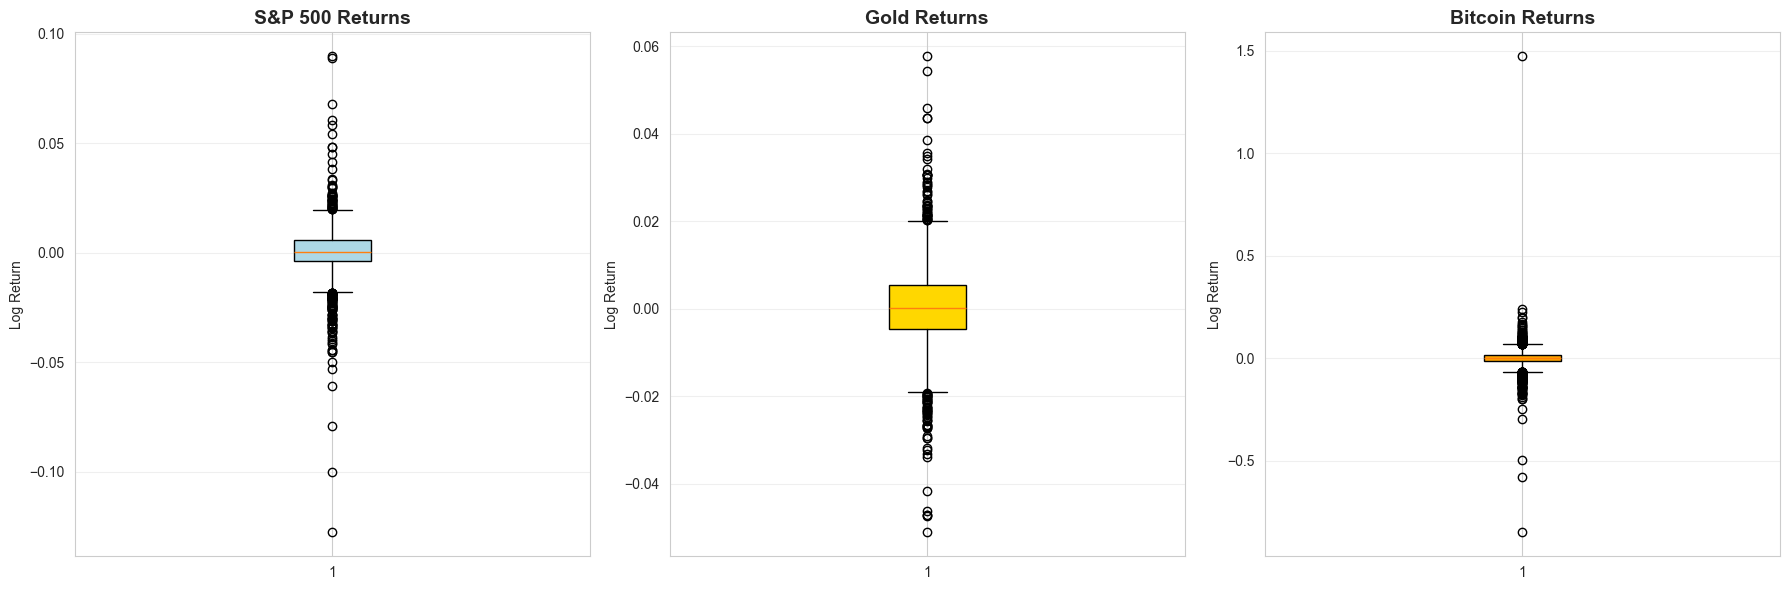

In [12]:
# Boxplots for returns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

returns = ['SP500_Return', 'Gold_Return', 'BTC_Return']
colors = ['lightblue', 'gold', 'orange']
titles = ['S&P 500 Returns', 'Gold Returns', 'Bitcoin Returns']

for i, (ret, color, title) in enumerate(zip(returns, colors, titles)):
    bp = axes[i].boxplot(df[ret].dropna(), patch_artist=True, vert=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Log Return')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

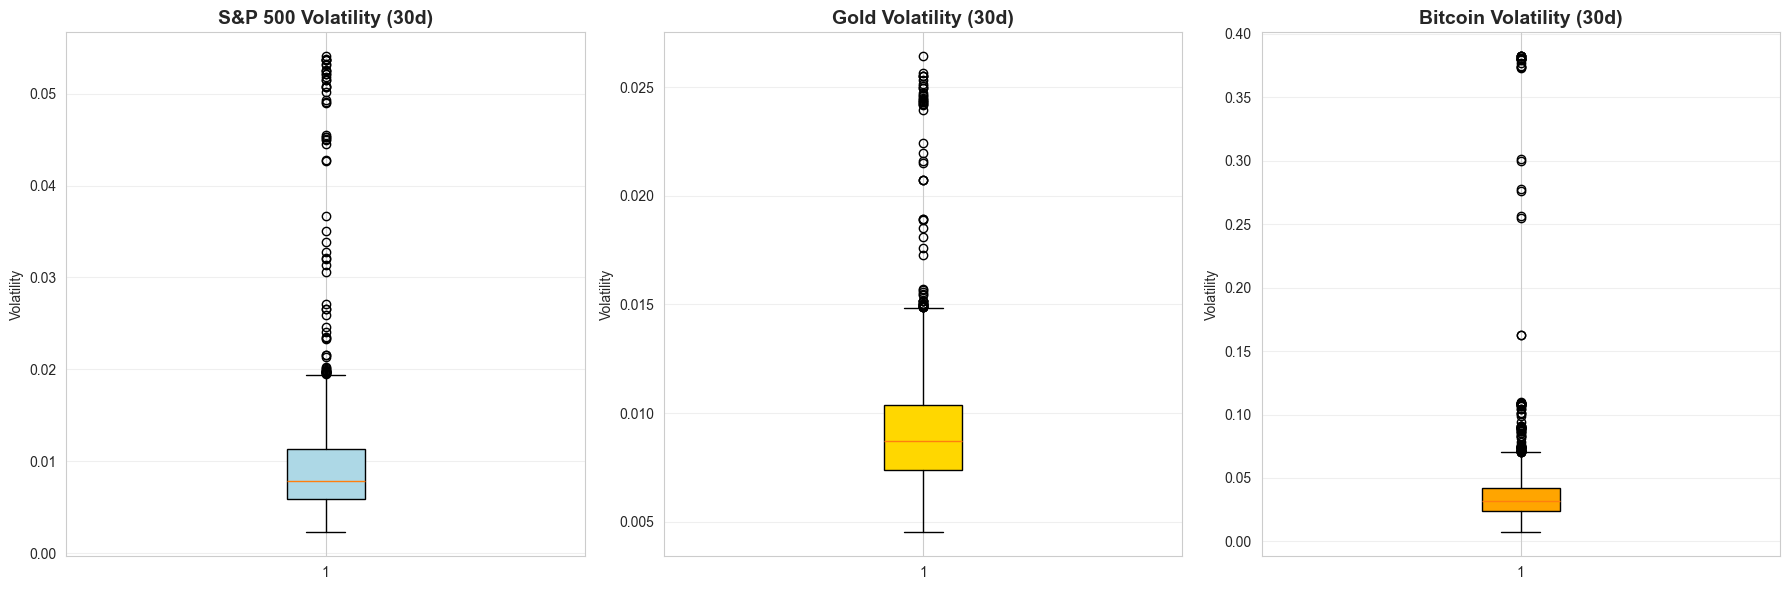

In [13]:
# Boxplots for 30-day volatilities
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vols = ['SP500_Vol30d', 'Gold_Vol30d', 'BTC_Vol30d']
colors = ['lightblue', 'gold', 'orange']
titles = ['S&P 500 Volatility (30d)', 'Gold Volatility (30d)', 'Bitcoin Volatility (30d)']

for i, (vol, color, title) in enumerate(zip(vols, colors, titles)):
    bp = axes[i].boxplot(df[vol].dropna(), patch_artist=True, vert=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Volatility')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Temporal Analysis

### 3.1 Time Series: EPU and Asset Volatilities

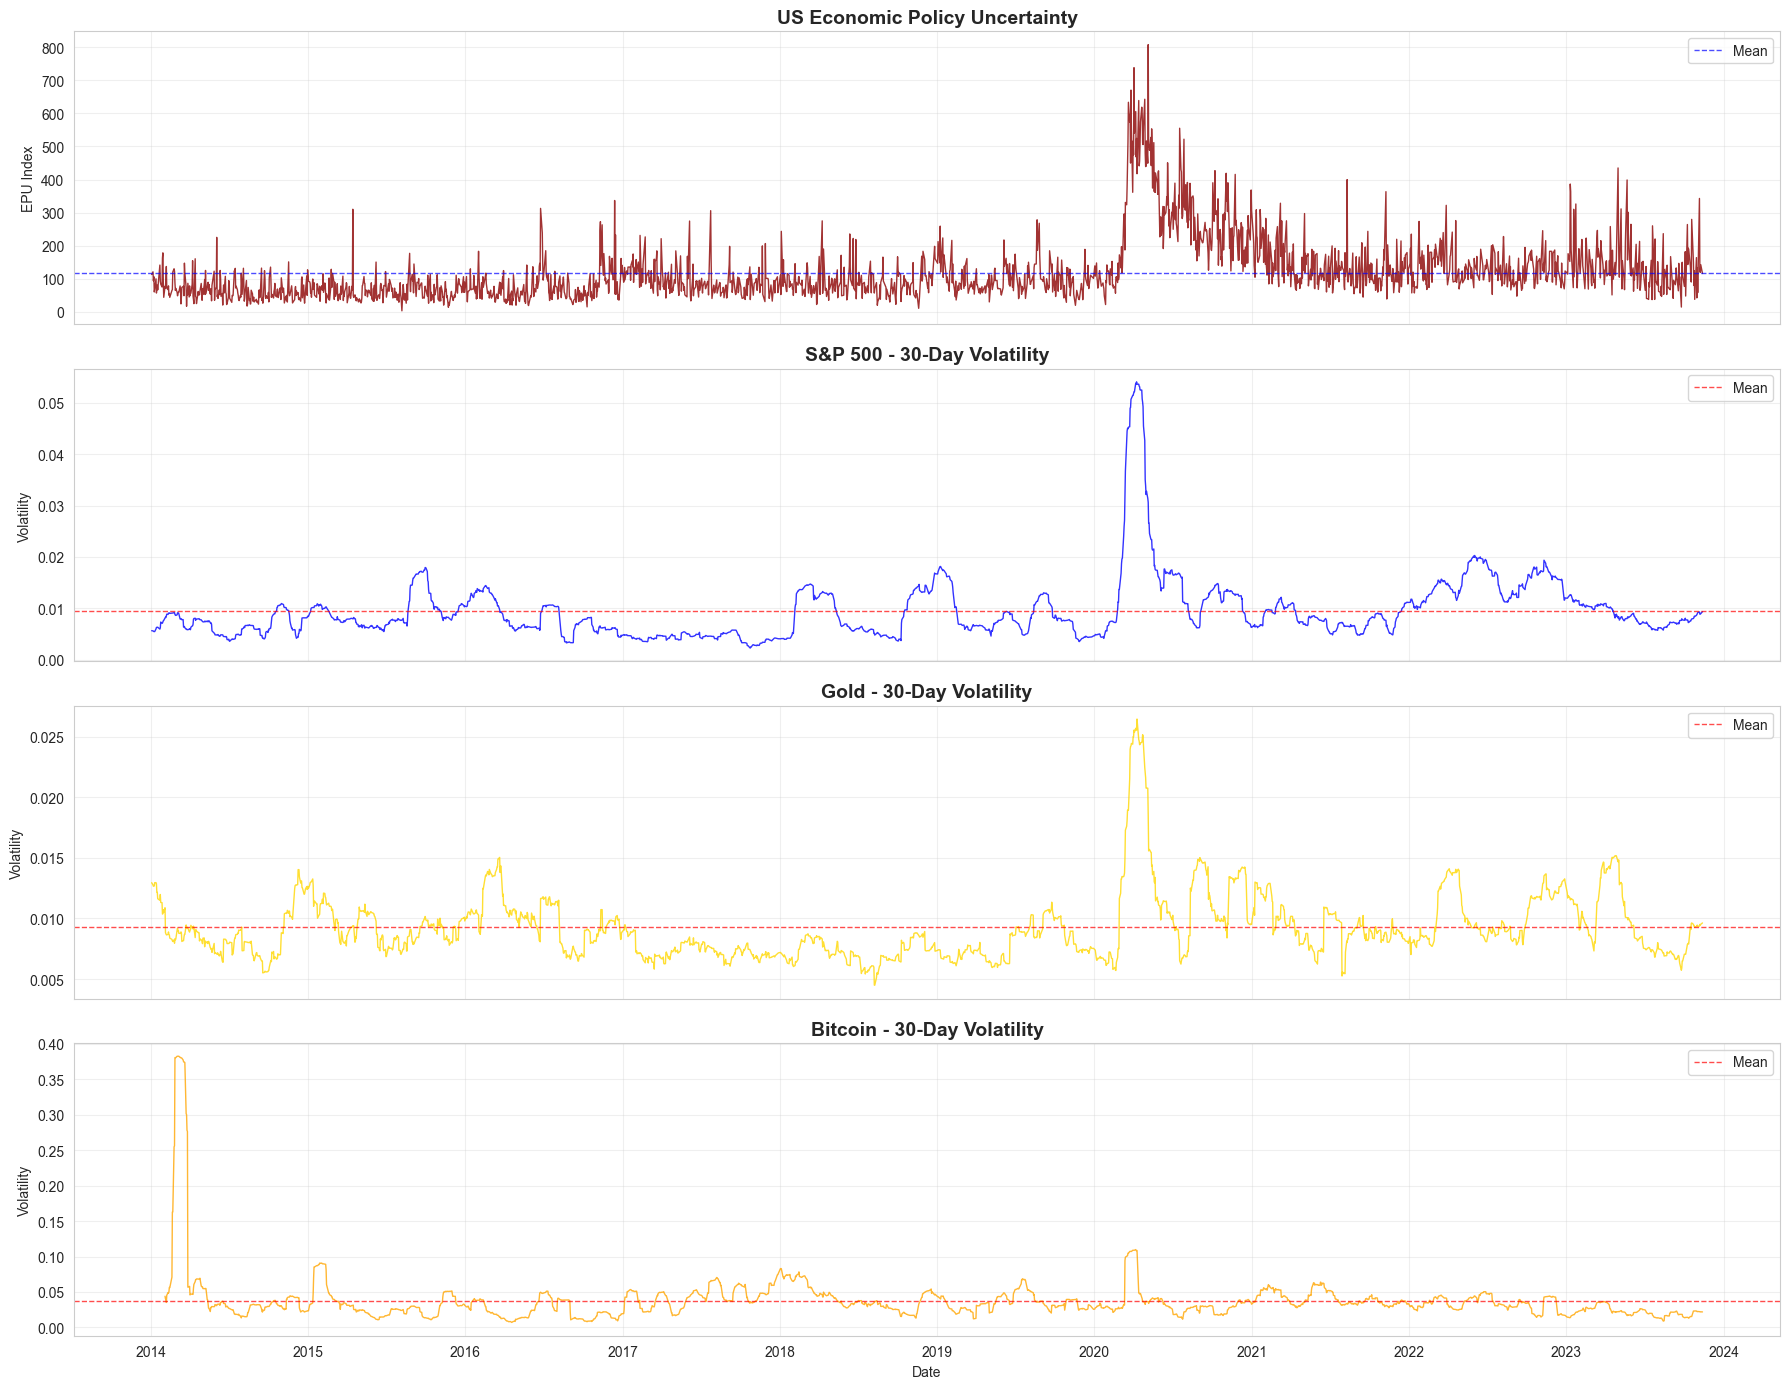

In [14]:
# Plot EPU and asset volatilities over time
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)

# EPU
axes[0].plot(df['Date'], df['EPU'], linewidth=1, color='darkred', alpha=0.8)
axes[0].axhline(df['EPU'].mean(), color='blue', linestyle='--', linewidth=1, alpha=0.7, label='Mean')
axes[0].set_title('US Economic Policy Uncertainty', fontsize=14, fontweight='bold')
axes[0].set_ylabel('EPU Index')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# S&P 500 Volatility
axes[1].plot(df['Date'], df['SP500_Vol30d'], linewidth=1, color='blue', alpha=0.8)
axes[1].axhline(df['SP500_Vol30d'].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7, label='Mean')
axes[1].set_title('S&P 500 - 30-Day Volatility', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gold Volatility
axes[2].plot(df['Date'], df['Gold_Vol30d'], linewidth=1, color='gold', alpha=0.8)
axes[2].axhline(df['Gold_Vol30d'].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7, label='Mean')
axes[2].set_title('Gold - 30-Day Volatility', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Volatility')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Bitcoin Volatility
axes[3].plot(df['Date'], df['BTC_Vol30d'], linewidth=1, color='orange', alpha=0.8)
axes[3].axhline(df['BTC_Vol30d'].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7, label='Mean')
axes[3].set_title('Bitcoin - 30-Day Volatility', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Volatility')
axes[3].set_xlabel('Date')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Rolling Correlations

In [15]:
# Calculate rolling correlations (30-day and 90-day windows)
window_30 = 30
window_90 = 90

# EPU vs SP500 volatility
df['EPU_SP500Vol_Corr30d'] = df['EPU'].rolling(window=window_30).corr(df['SP500_Vol30d'])
df['EPU_SP500Vol_Corr90d'] = df['EPU'].rolling(window=window_90).corr(df['SP500_Vol30d'])

# EPU vs Gold volatility
df['EPU_GoldVol_Corr30d'] = df['EPU'].rolling(window=window_30).corr(df['Gold_Vol30d'])
df['EPU_GoldVol_Corr90d'] = df['EPU'].rolling(window=window_90).corr(df['Gold_Vol30d'])

# EPU vs Bitcoin volatility
df['EPU_BTCVol_Corr30d'] = df['EPU'].rolling(window=window_30).corr(df['BTC_Vol30d'])
df['EPU_BTCVol_Corr90d'] = df['EPU'].rolling(window=window_90).corr(df['BTC_Vol30d'])

print("Rolling correlations calculated.")

Rolling correlations calculated.


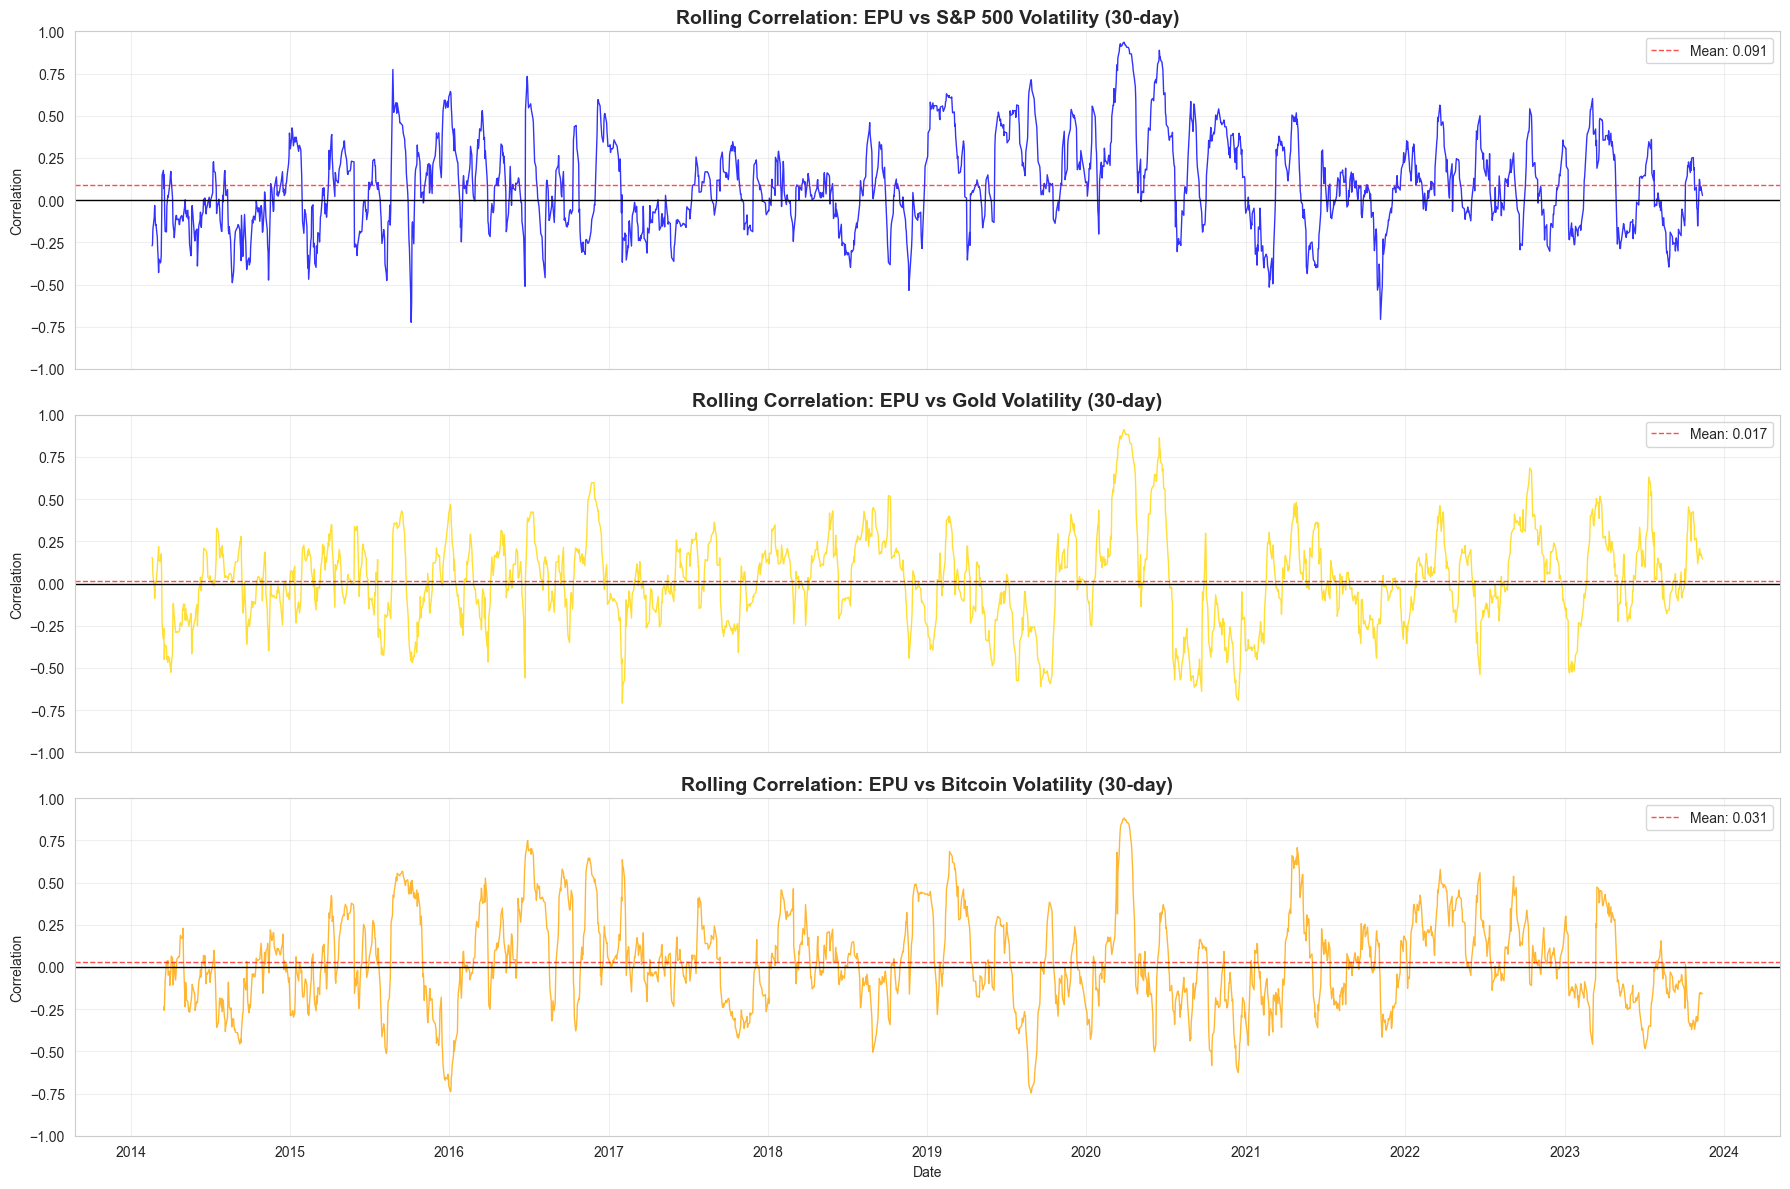

In [16]:
# Plot rolling correlations (30-day window)
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# EPU vs SP500 Vol
axes[0].plot(df['Date'], df['EPU_SP500Vol_Corr30d'], linewidth=1, color='blue', alpha=0.8)
axes[0].axhline(0, color='black', linestyle='-', linewidth=1)
axes[0].axhline(df['EPU_SP500Vol_Corr30d'].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7, 
                label=f'Mean: {df["EPU_SP500Vol_Corr30d"].mean():.3f}')
axes[0].set_title('Rolling Correlation: EPU vs S&P 500 Volatility (30-day)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Correlation')
axes[0].set_ylim(-1, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# EPU vs Gold Vol
axes[1].plot(df['Date'], df['EPU_GoldVol_Corr30d'], linewidth=1, color='gold', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[1].axhline(df['EPU_GoldVol_Corr30d'].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Mean: {df["EPU_GoldVol_Corr30d"].mean():.3f}')
axes[1].set_title('Rolling Correlation: EPU vs Gold Volatility (30-day)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Correlation')
axes[1].set_ylim(-1, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# EPU vs BTC Vol
axes[2].plot(df['Date'], df['EPU_BTCVol_Corr30d'], linewidth=1, color='orange', alpha=0.8)
axes[2].axhline(0, color='black', linestyle='-', linewidth=1)
axes[2].axhline(df['EPU_BTCVol_Corr30d'].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Mean: {df["EPU_BTCVol_Corr30d"].mean():.3f}')
axes[2].set_title('Rolling Correlation: EPU vs Bitcoin Volatility (30-day)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Correlation')
axes[2].set_xlabel('Date')
axes[2].set_ylim(-1, 1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

### 4.1 Static Correlation Matrix

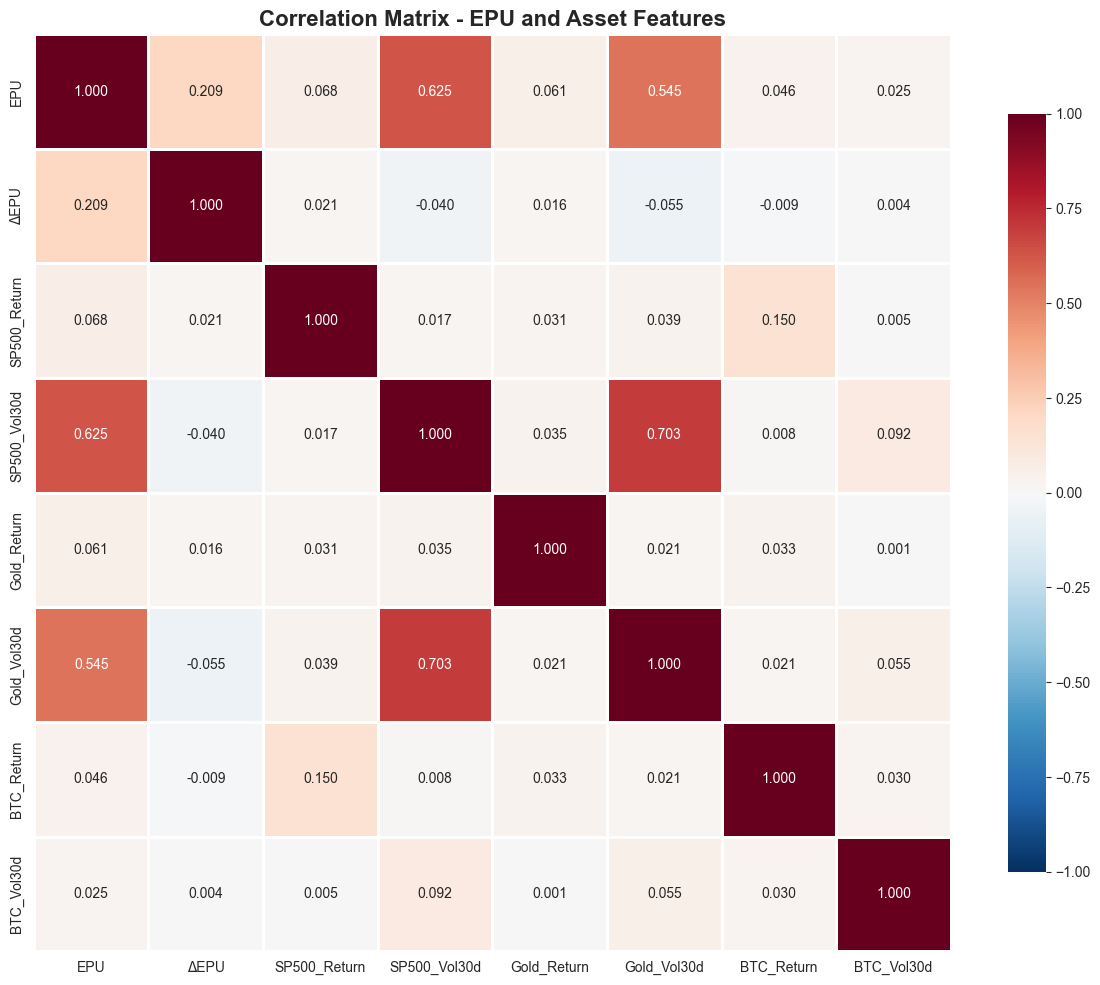


Key Correlations with EPU:
EPU             1.000000
SP500_Vol30d    0.625469
Gold_Vol30d     0.545038
ΔEPU            0.209484
SP500_Return    0.067984
Gold_Return     0.061032
BTC_Return      0.045589
BTC_Vol30d      0.025439
Name: EPU, dtype: float64

Key Correlations with ΔEPU:
ΔEPU            1.000000
EPU             0.209484
SP500_Return    0.020697
Gold_Return     0.016256
BTC_Vol30d      0.004038
BTC_Return     -0.008741
SP500_Vol30d   -0.040064
Gold_Vol30d    -0.054718
Name: ΔEPU, dtype: float64


In [17]:
# Correlation matrix for key features
corr_features = ['EPU', 'ΔEPU', 'SP500_Return', 'SP500_Vol30d', 
                 'Gold_Return', 'Gold_Vol30d', 'BTC_Return', 'BTC_Vol30d']

corr_matrix = df[corr_features].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - EPU and Asset Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key correlations
print("\nKey Correlations with EPU:")
epu_corrs = corr_matrix['EPU'].sort_values(ascending=False)
print(epu_corrs)

print("\nKey Correlations with ΔEPU:")
depu_corrs = corr_matrix['ΔEPU'].sort_values(ascending=False)
print(depu_corrs)

### 4.2 Scatter Plots with Regression

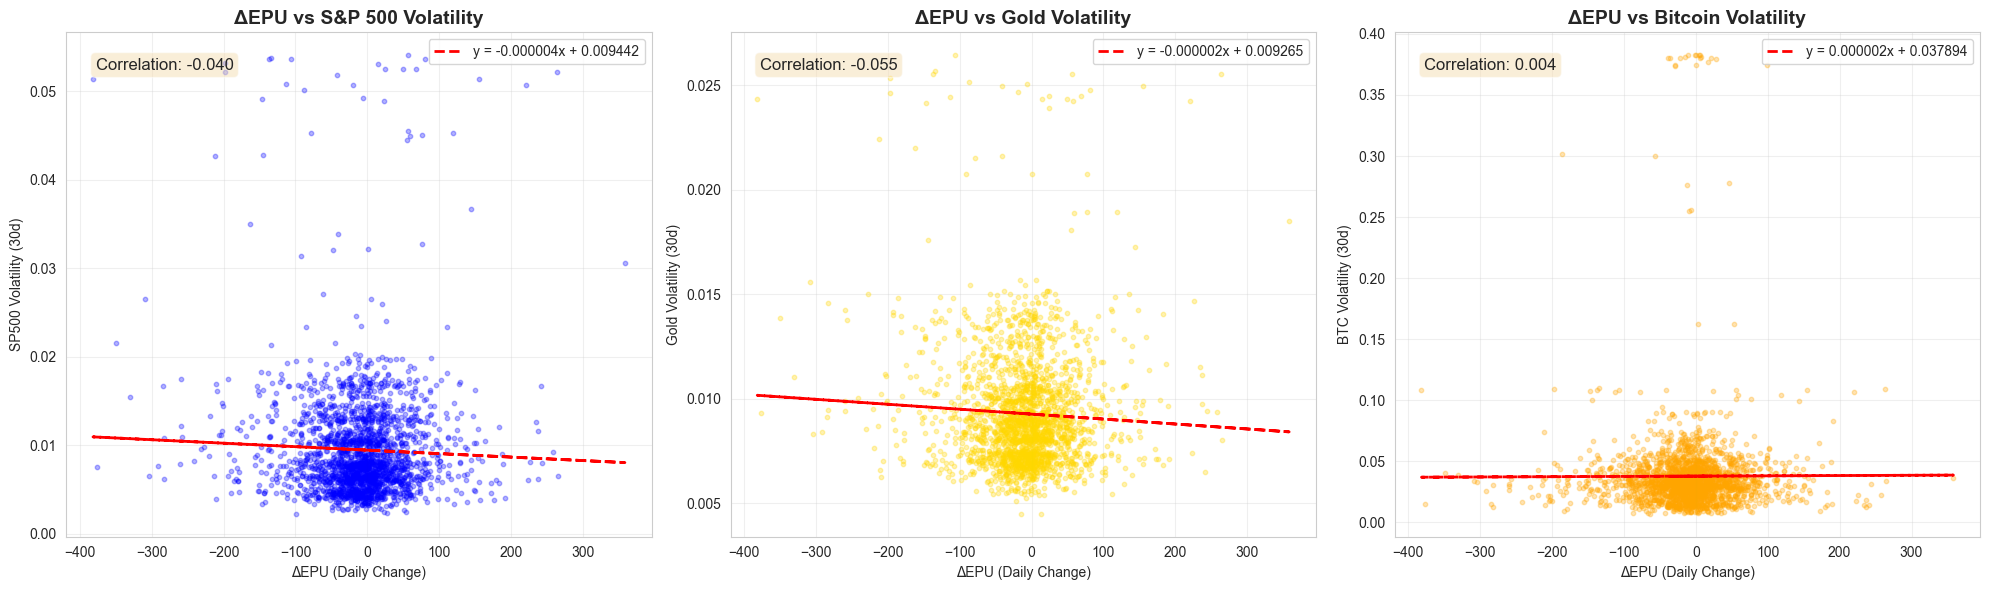

In [18]:
# Scatter plots: ΔEPU vs asset volatilities
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

vols = ['SP500_Vol30d', 'Gold_Vol30d', 'BTC_Vol30d']
colors = ['blue', 'gold', 'orange']
titles = ['ΔEPU vs S&P 500 Volatility', 'ΔEPU vs Gold Volatility', 'ΔEPU vs Bitcoin Volatility']

for i, (vol, color, title) in enumerate(zip(vols, colors, titles)):
    # Drop NaN values
    data = df[['ΔEPU', vol]].dropna()
    
    # Scatter plot
    axes[i].scatter(data['ΔEPU'], data[vol], alpha=0.3, s=10, color=color)
    
    # Regression line
    z = np.polyfit(data['ΔEPU'], data[vol], 1)
    p = np.poly1d(z)
    axes[i].plot(data['ΔEPU'], p(data['ΔEPU']), "r--", linewidth=2, 
                 label=f'y = {z[0]:.6f}x + {z[1]:.6f}')
    
    # Correlation
    corr = data['ΔEPU'].corr(data[vol])
    axes[i].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                 transform=axes[i].transAxes, fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('ΔEPU (Daily Change)')
    axes[i].set_ylabel(f'{vol.split("_")[0]} Volatility (30d)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Quantile Analysis

### 5.1 EPU Quintile Stratification

Mean Volatility by EPU Quintile:


,SP500_Vol30d,Gold_Vol30d,BTC_Vol30d
EPU_Quintile,,,
Q1 (Low),0.007432,0.008719,0.035805
Q2,0.008049,0.008572,0.043394
Q3,0.008407,0.008642,0.036531
Q4,0.009195,0.009134,0.037324
Q5 (High),0.014324,0.011379,0.036340


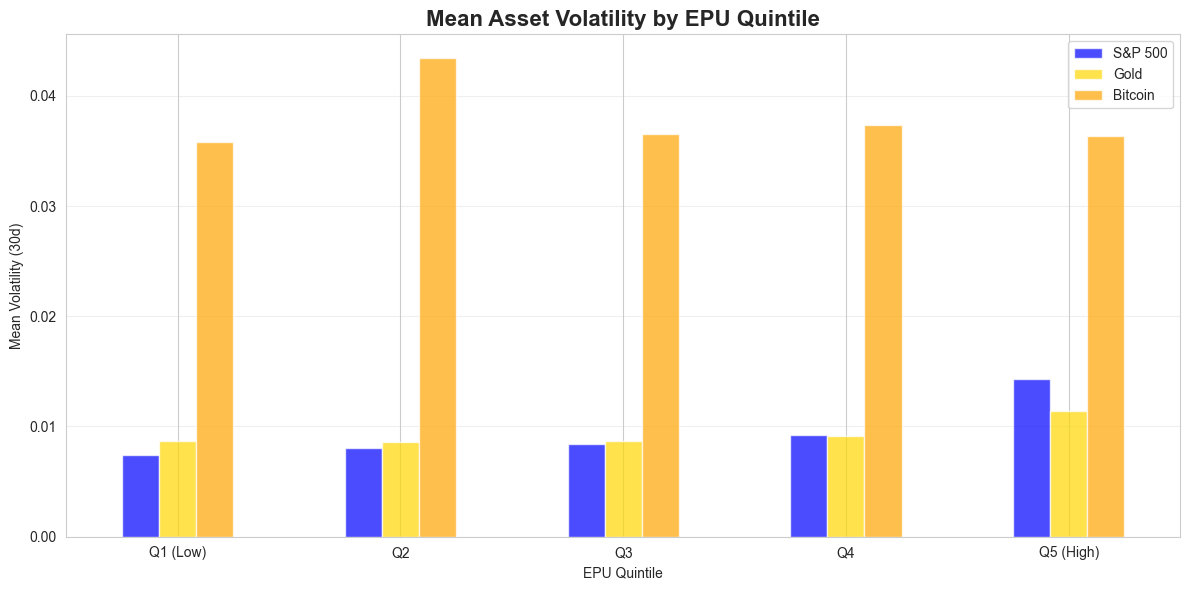

In [19]:
# Create EPU quintiles
df['EPU_Quintile'] = pd.qcut(df['EPU'], q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

# Calculate mean volatility by quintile
quintile_stats = df.groupby('EPU_Quintile')[['SP500_Vol30d', 'Gold_Vol30d', 'BTC_Vol30d']].mean()

print("Mean Volatility by EPU Quintile:")
display(quintile_stats)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
quintile_stats.plot(kind='bar', ax=ax, color=['blue', 'gold', 'orange'], alpha=0.7)
ax.set_title('Mean Asset Volatility by EPU Quintile', fontsize=16, fontweight='bold')
ax.set_xlabel('EPU Quintile')
ax.set_ylabel('Mean Volatility (30d)')
ax.legend(['S&P 500', 'Gold', 'Bitcoin'])
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 ΔEPU Quintile Stratification

Mean Volatility by ΔEPU Quintile:


,SP500_Vol30d,Gold_Vol30d,BTC_Vol30d
ΔEPU_Quintile,,,
Q1 (Large Decrease),0.010794,0.009939,0.036000
Q2,0.008714,0.008873,0.038133
Q3,0.008509,0.008910,0.039202
Q4,0.009027,0.009154,0.038876
Q5 (Large Increase),0.010365,0.009571,0.037155


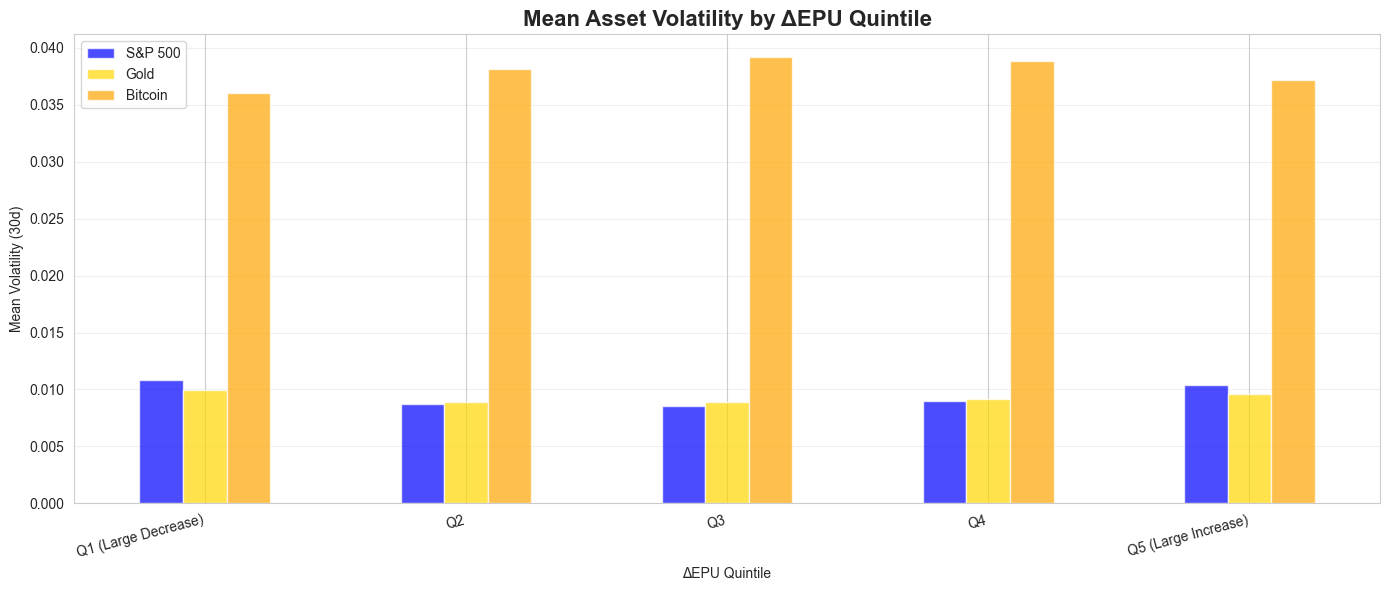

In [20]:
# Create ΔEPU quintiles
df['ΔEPU_Quintile'] = pd.qcut(df['ΔEPU'], q=5, labels=['Q1 (Large Decrease)', 'Q2', 'Q3', 'Q4', 'Q5 (Large Increase)'])

# Calculate mean volatility by quintile
depu_quintile_stats = df.groupby('ΔEPU_Quintile')[['SP500_Vol30d', 'Gold_Vol30d', 'BTC_Vol30d']].mean()

print("Mean Volatility by ΔEPU Quintile:")
display(depu_quintile_stats)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
depu_quintile_stats.plot(kind='bar', ax=ax, color=['blue', 'gold', 'orange'], alpha=0.7)
ax.set_title('Mean Asset Volatility by ΔEPU Quintile', fontsize=16, fontweight='bold')
ax.set_xlabel('ΔEPU Quintile')
ax.set_ylabel('Mean Volatility (30d)')
ax.legend(['S&P 500', 'Gold', 'Bitcoin'])
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Shock Analysis

Shock threshold (90th percentile): 99.12
Number of shock days: 223 (10.0%)

Mean Volatility: Shock vs Normal Periods:


,SP500_Vol30d,Gold_Vol30d,BTC_Vol30d
Normal,0.009124,0.009126,0.037831
Shock,0.012708,0.010768,0.038209


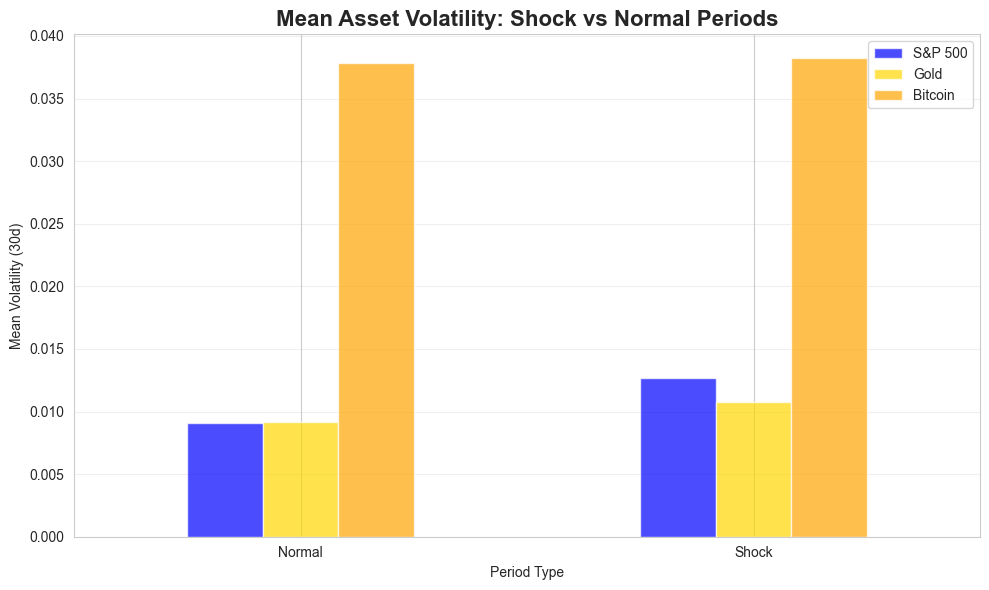

In [21]:
# Define shock periods (top 10% of ΔEPU absolute changes)
threshold = df['ΔEPU'].abs().quantile(0.90)
df['Is_Shock'] = df['ΔEPU'].abs() > threshold

print(f"Shock threshold (90th percentile): {threshold:.2f}")
print(f"Number of shock days: {df['Is_Shock'].sum()} ({df['Is_Shock'].sum() / len(df) * 100:.1f}%)")

# Compare volatility during shock vs normal periods
shock_comparison = df.groupby('Is_Shock')[['SP500_Vol30d', 'Gold_Vol30d', 'BTC_Vol30d']].mean()
shock_comparison.index = ['Normal', 'Shock']

print("\nMean Volatility: Shock vs Normal Periods:")
display(shock_comparison)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
shock_comparison.plot(kind='bar', ax=ax, color=['blue', 'gold', 'orange'], alpha=0.7)
ax.set_title('Mean Asset Volatility: Shock vs Normal Periods', fontsize=16, fontweight='bold')
ax.set_xlabel('Period Type')
ax.set_ylabel('Mean Volatility (30d)')
ax.legend(['S&P 500', 'Gold', 'Bitcoin'])
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Lead-Lag Analysis

### 6.1 Lagged Correlations

Lagged Correlations (EPU_{t-lag} vs Vol_t):


,SP500,Gold,BTC
Lag (days),,,
0,0.625469,0.545038,0.025439
1,0.618268,0.545779,0.025369
2,0.611707,0.545955,0.023326
3,0.604113,0.545144,0.024707
4,0.594798,0.538827,0.020111
5,0.583591,0.537700,0.016495
6,0.572150,0.531583,0.011238
7,0.559499,0.525678,0.009185


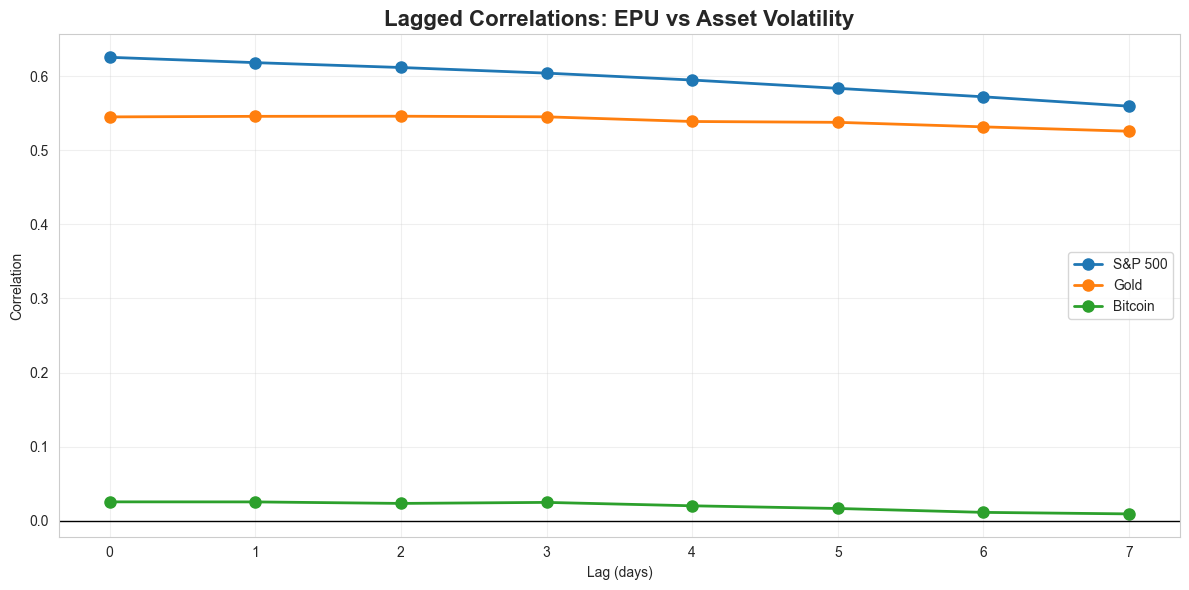

In [22]:
# Calculate lagged correlations (EPU lags 0-7 days vs current volatility)
max_lag = 7
lag_corrs = {}

for asset in ['SP500', 'Gold', 'BTC']:
    vol_col = f'{asset}_Vol30d'
    lag_corrs[asset] = []
    
    for lag in range(max_lag + 1):
        if lag == 0:
            corr = df['EPU'].corr(df[vol_col])
        else:
            corr = df['EPU'].shift(lag).corr(df[vol_col])
        lag_corrs[asset].append(corr)

# Create DataFrame
lag_corrs_df = pd.DataFrame(lag_corrs, index=range(max_lag + 1))
lag_corrs_df.index.name = 'Lag (days)'

print("Lagged Correlations (EPU_{t-lag} vs Vol_t):")
display(lag_corrs_df)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
lag_corrs_df.plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=8)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_title('Lagged Correlations: EPU vs Asset Volatility', fontsize=16, fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Correlation')
ax.legend(['S&P 500', 'Gold', 'Bitcoin'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Lagged Correlations (ΔEPU_{t-lag} vs Vol_t):


,SP500,Gold,BTC
Lag (days),,,
0,-0.040064,-0.054718,0.004038
1,-0.036434,-0.051296,0.006094
2,-0.035000,-0.049144,0.001630
3,-0.032259,-0.041629,0.007932
4,-0.028475,-0.047173,0.016285
5,-0.028816,-0.034821,0.019503
6,-0.025825,-0.032868,0.014301
7,-0.023476,-0.031722,0.015698


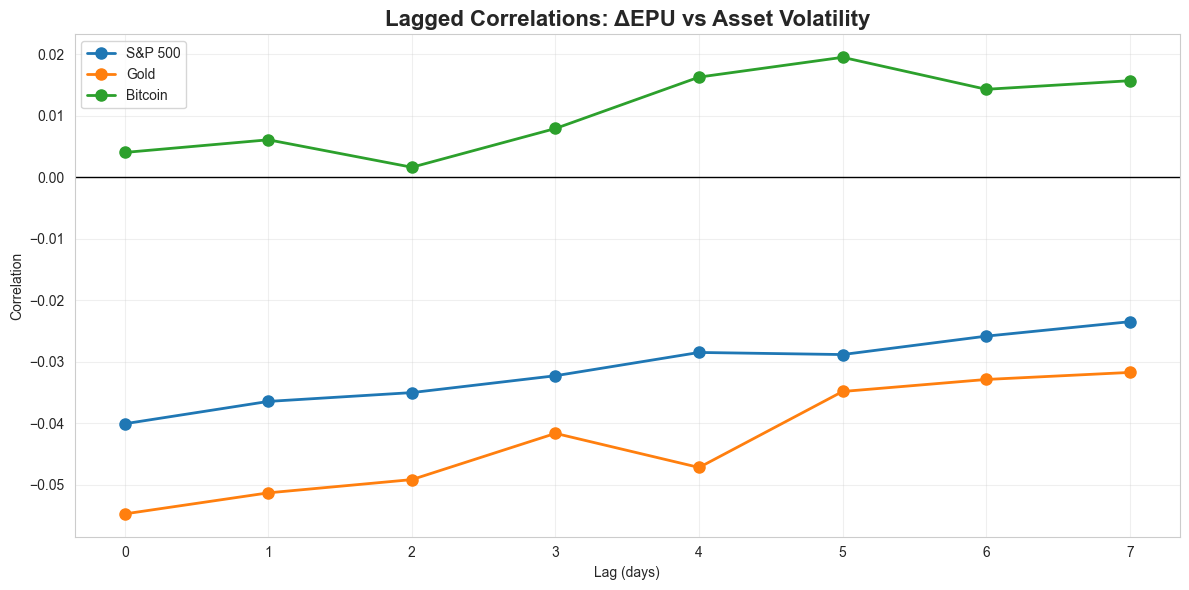

In [23]:
# Calculate lagged correlations for ΔEPU
depu_lag_corrs = {}

for asset in ['SP500', 'Gold', 'BTC']:
    vol_col = f'{asset}_Vol30d'
    depu_lag_corrs[asset] = []
    
    for lag in range(max_lag + 1):
        if lag == 0:
            corr = df['ΔEPU'].corr(df[vol_col])
        else:
            corr = df['ΔEPU'].shift(lag).corr(df[vol_col])
        depu_lag_corrs[asset].append(corr)

# Create DataFrame
depu_lag_corrs_df = pd.DataFrame(depu_lag_corrs, index=range(max_lag + 1))
depu_lag_corrs_df.index.name = 'Lag (days)'

print("Lagged Correlations (ΔEPU_{t-lag} vs Vol_t):")
display(depu_lag_corrs_df)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
depu_lag_corrs_df.plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=8)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_title('Lagged Correlations: ΔEPU vs Asset Volatility', fontsize=16, fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Correlation')
ax.legend(['S&P 500', 'Gold', 'Bitcoin'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Granger Causality Tests

In [24]:
# Granger causality test: Does EPU Granger-cause SP500 volatility?
print("=" * 80)
print("Granger Causality Test: EPU → S&P 500 Volatility")
print("=" * 80)

# Prepare data (drop NaN)
granger_data = df[['EPU', 'SP500_Vol30d']].dropna()

# Run test (lags 1-5)
try:
    gc_result = grangercausalitytests(granger_data[['SP500_Vol30d', 'EPU']], maxlag=5, verbose=True)
except Exception as e:
    print(f"Error: {e}")

Granger Causality Test: EPU → S&P 500 Volatility

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=9.4548  , p=0.0021  , df_denom=2223, df_num=1
ssr based chi2 test:   chi2=9.4676  , p=0.0021  , df=1
likelihood ratio test: chi2=9.4475  , p=0.0021  , df=1
parameter F test:         F=9.4548  , p=0.0021  , df_denom=2223, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.2890  , p=0.1016  , df_denom=2220, df_num=2
ssr based chi2 test:   chi2=4.5882  , p=0.1009  , df=2
likelihood ratio test: chi2=4.5835  , p=0.1011  , df=2
parameter F test:         F=2.2890  , p=0.1016  , df_denom=2220, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7457  , p=0.5248  , df_denom=2217, df_num=3
ssr based chi2 test:   chi2=2.2442  , p=0.5233  , df=3
likelihood ratio test: chi2=2.2431  , p=0.5235  , df=3
parameter F test:         F=0.7457  , p=0.5248  , df_denom=2217, df_num=3

Granger Causality
number of lags (no z

In [25]:
# Granger causality test: Does EPU Granger-cause Gold volatility?
print("=" * 80)
print("Granger Causality Test: EPU → Gold Volatility")
print("=" * 80)

# Prepare data
granger_data = df[['EPU', 'Gold_Vol30d']].dropna()

# Run test
try:
    gc_result = grangercausalitytests(granger_data[['Gold_Vol30d', 'EPU']], maxlag=5, verbose=True)
except Exception as e:
    print(f"Error: {e}")

Granger Causality Test: EPU → Gold Volatility

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=8.2943  , p=0.0040  , df_denom=2223, df_num=1
ssr based chi2 test:   chi2=8.3055  , p=0.0040  , df=1
likelihood ratio test: chi2=8.2901  , p=0.0040  , df=1
parameter F test:         F=8.2943  , p=0.0040  , df_denom=2223, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.8420  , p=0.0080  , df_denom=2220, df_num=2
ssr based chi2 test:   chi2=9.7058  , p=0.0078  , df=2
likelihood ratio test: chi2=9.6847  , p=0.0079  , df=2
parameter F test:         F=4.8420  , p=0.0080  , df_denom=2220, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.7112  , p=0.0112  , df_denom=2217, df_num=3
ssr based chi2 test:   chi2=11.1688 , p=0.0108  , df=3
likelihood ratio test: chi2=11.1408 , p=0.0110  , df=3
parameter F test:         F=3.7112  , p=0.0112  , df_denom=2217, df_num=3

Granger Causality
number of lags (no zero

In [26]:
# Granger causality test: Does EPU Granger-cause Bitcoin volatility?
print("=" * 80)
print("Granger Causality Test: EPU → Bitcoin Volatility")
print("=" * 80)

# Prepare data
granger_data = df[['EPU', 'BTC_Vol30d']].dropna()

# Run test
try:
    gc_result = grangercausalitytests(granger_data[['BTC_Vol30d', 'EPU']], maxlag=5, verbose=True)
except Exception as e:
    print(f"Error: {e}")

Granger Causality Test: EPU → Bitcoin Volatility

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0127  , p=0.9102  , df_denom=2204, df_num=1
ssr based chi2 test:   chi2=0.0127  , p=0.9101  , df=1
likelihood ratio test: chi2=0.0127  , p=0.9101  , df=1
parameter F test:         F=0.0127  , p=0.9102  , df_denom=2204, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3433  , p=0.7095  , df_denom=2201, df_num=2
ssr based chi2 test:   chi2=0.6881  , p=0.7089  , df=2
likelihood ratio test: chi2=0.6880  , p=0.7089  , df=2
parameter F test:         F=0.3433  , p=0.7095  , df_denom=2201, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.4632  , p=0.7080  , df_denom=2198, df_num=3
ssr based chi2 test:   chi2=1.3940  , p=0.7069  , df=3
likelihood ratio test: chi2=1.3935  , p=0.7071  , df=3
parameter F test:         F=0.4632  , p=0.7080  , df_denom=2198, df_num=3

Granger Causality
number of lags (no z

## 7. Key Findings Summary

In [27]:
print("=" * 80)
print("KEY FINDINGS SUMMARY")
print("=" * 80)

print("\n1. DESCRIPTIVE STATISTICS")
print("-" * 80)
print(f"   - EPU Mean: {df['EPU'].mean():.2f}, Std: {df['EPU'].std():.2f}")
print(f"   - ΔEPU Mean: {df['ΔEPU'].mean():.2f}, Std: {df['ΔEPU'].std():.2f}")
print(f"   - S&P 500 Vol (30d) Mean: {df['SP500_Vol30d'].mean():.4f}")
print(f"   - Gold Vol (30d) Mean: {df['Gold_Vol30d'].mean():.4f}")
print(f"   - Bitcoin Vol (30d) Mean: {df['BTC_Vol30d'].mean():.4f}")

print("\n2. STATIC CORRELATIONS")
print("-" * 80)
print(f"   - EPU vs S&P 500 Vol: {df['EPU'].corr(df['SP500_Vol30d']):.3f}")
print(f"   - EPU vs Gold Vol: {df['EPU'].corr(df['Gold_Vol30d']):.3f}")
print(f"   - EPU vs Bitcoin Vol: {df['EPU'].corr(df['BTC_Vol30d']):.3f}")
print(f"   - ΔEPU vs S&P 500 Vol: {df['ΔEPU'].corr(df['SP500_Vol30d']):.3f}")
print(f"   - ΔEPU vs Gold Vol: {df['ΔEPU'].corr(df['Gold_Vol30d']):.3f}")
print(f"   - ΔEPU vs Bitcoin Vol: {df['ΔEPU'].corr(df['BTC_Vol30d']):.3f}")

print("\n3. ROLLING CORRELATIONS (30-day)")
print("-" * 80)
print(f"   - EPU vs S&P 500 Vol Mean: {df['EPU_SP500Vol_Corr30d'].mean():.3f}")
print(f"   - EPU vs Gold Vol Mean: {df['EPU_GoldVol_Corr30d'].mean():.3f}")
print(f"   - EPU vs Bitcoin Vol Mean: {df['EPU_BTCVol_Corr30d'].mean():.3f}")

print("\n4. QUANTILE ANALYSIS")
print("-" * 80)
print("   EPU Quintile Volatility Differences:")
print(f"   - S&P 500: Q5/Q1 ratio = {quintile_stats.loc['Q5 (High)', 'SP500_Vol30d'] / quintile_stats.loc['Q1 (Low)', 'SP500_Vol30d']:.2f}x")
print(f"   - Gold: Q5/Q1 ratio = {quintile_stats.loc['Q5 (High)', 'Gold_Vol30d'] / quintile_stats.loc['Q1 (Low)', 'Gold_Vol30d']:.2f}x")
print(f"   - Bitcoin: Q5/Q1 ratio = {quintile_stats.loc['Q5 (High)', 'BTC_Vol30d'] / quintile_stats.loc['Q1 (Low)', 'BTC_Vol30d']:.2f}x")

print("\n5. SHOCK ANALYSIS")
print("-" * 80)
print(f"   - Shock days: {df['Is_Shock'].sum()} ({df['Is_Shock'].sum() / len(df) * 100:.1f}%)")
print(f"   - S&P 500 Vol: Shock/Normal ratio = {shock_comparison.loc['Shock', 'SP500_Vol30d'] / shock_comparison.loc['Normal', 'SP500_Vol30d']:.2f}x")
print(f"   - Gold Vol: Shock/Normal ratio = {shock_comparison.loc['Shock', 'Gold_Vol30d'] / shock_comparison.loc['Normal', 'Gold_Vol30d']:.2f}x")
print(f"   - Bitcoin Vol: Shock/Normal ratio = {shock_comparison.loc['Shock', 'BTC_Vol30d'] / shock_comparison.loc['Normal', 'BTC_Vol30d']:.2f}x")

print("\n6. LEAD-LAG ANALYSIS")
print("-" * 80)
print("   Strongest lagged correlations (EPU):")
for asset in ['SP500', 'Gold', 'BTC']:
    max_corr_idx = lag_corrs_df[asset].abs().idxmax()
    max_corr = lag_corrs_df.loc[max_corr_idx, asset]
    print(f"   - {asset}: Lag {max_corr_idx} days, Corr = {max_corr:.3f}")

print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR MODELING")
print("=" * 80)
print("\n1. FEATURE SELECTION:")
print("   - Include EPU level and ΔEPU as primary features")
print("   - Consider lagged EPU values (1-3 days) based on correlation analysis")
print("   - EPU_MA30 and EPU_Std30 may capture regime changes")

print("\n2. TARGET SELECTION:")
print("   - 30-day volatility shows strongest and most stable relationships")
print("   - Consider separate models for each asset due to different dynamics")

print("\n3. MODEL COMPLEXITY:")
print("   - Quantile analysis suggests non-linear relationships")
print("   - Consider quantile regression or regime-switching models")
print("   - Rolling correlations show time-varying relationships")

print("\n4. TEMPORAL DYNAMICS:")
print("   - Lead-lag analysis suggests EPU has predictive power (not just reactive)")
print("   - Granger causality tests provide formal evidence")
print("   - Consider time-series models (VAR, GARCH) or ML with lagged features")

print("\n" + "=" * 80)

KEY FINDINGS SUMMARY

1. DESCRIPTIVE STATISTICS
--------------------------------------------------------------------------------
   - EPU Mean: 118.73, Std: 93.58
   - ΔEPU Mean: -10.47, Std: 64.84
   - S&P 500 Vol (30d) Mean: 0.0095
   - Gold Vol (30d) Mean: 0.0093
   - Bitcoin Vol (30d) Mean: 0.0379

2. STATIC CORRELATIONS
--------------------------------------------------------------------------------
   - EPU vs S&P 500 Vol: 0.625
   - EPU vs Gold Vol: 0.545
   - EPU vs Bitcoin Vol: 0.025
   - ΔEPU vs S&P 500 Vol: -0.040
   - ΔEPU vs Gold Vol: -0.055
   - ΔEPU vs Bitcoin Vol: 0.004

3. ROLLING CORRELATIONS (30-day)
--------------------------------------------------------------------------------
   - EPU vs S&P 500 Vol Mean: 0.091
   - EPU vs Gold Vol Mean: 0.017
   - EPU vs Bitcoin Vol Mean: 0.031

4. QUANTILE ANALYSIS
--------------------------------------------------------------------------------
   EPU Quintile Volatility Differences:
   - S&P 500: Q5/Q1 ratio = 1.93x
   - Gold: